# Test-Szenario A1
Wie gut können LLMs Feebdack zu den gegebenen Antworten geben?
_Könnte **Test-Szenarien S7, S8, S9** abdecken_

_Anwendbar auch für Test-Szenarien 3 und 4_
- _**Test-Szenario A3**: Evaluierung von verbesserten Spracheingaben -> wie oft wird das Gesprochene wie erwartet bewertet?_
- _**Test-Szenario A4**: Evaluierung von invarianten Spracheingaben -> wie oft, trotz Fehlern in der Eingabe, wird das Gesprochene wie erwartet bewertet? (deckt **Test-Szenario S3** ab)_
- _**Test-Szenario S2**: Erfolgt eine Ergänzungs-/Rückfrage wie erwartet?_

## Load Input Data

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

dir_path = Path(".")  # current directory
keep_cols = ["question_de", "answer_de", "max_points", "keywords", "transkript_stt_model", "human_score", "human_feedback",
             "rueckfrage", "error_type"]

dfs = []
for fp in sorted(dir_path.glob("*.tsv")):
    df_tmp = pd.read_csv(fp, sep="\t", dtype=str)
    df_tmp = df_tmp.reindex(columns=keep_cols)  # keeps order, fills missing with NA
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)  # appends; duplicates are kept
df["max_points"] = df["max_points"].str.replace(",", ".").astype(float)
df["human_score"] = df["human_score"].str.replace(",", ".").astype(float)
df["error_type"] = df["error_type"].astype(int)
df["rueckfrage"] = df["rueckfrage"].astype(int)

# check for column names: question_text, transkript_stt_model, gold_answer, maximal_score, human_score, human_feedback
df.head()

,question_de,answer_de,max_points,keywords,transkript_stt_model,human_score,human_feedback,rueckfrage,error_type
0,Was ist der Zweck von t-Tests in der EDA?,"T-Tests in der EDA werden verwendet, um die Mi...",6.0,t-Tests; unabhängige Stichproben; bekannter We...,EDA steht für explorative Datenanalyse. Tests ...,6.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
1,Was ist der Zweck nicht-parametrischer Tests i...,Nicht-parametrische Tests in der EDA werden ve...,4.0,nicht-parametrische Tests; EDA; Annahmen param...,Nicht parametrische Tests in der idea werden v...,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
2,Was ist der Zweck der explorativen Faktorenana...,Die explorative Faktorenanalyse (EFA) im Rahme...,4.0,explorative Faktorenanalyse; EDA; zugrunde lie...,"Der Zweck besteht darin, die Ursache oder aber...",4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0,1
3,Was ist der Unterschied zwischen EFA und Haupt...,EFA und PCA sind beide Verfahren zur Reduktion...,6.0,EFA; PCA; Dimensionality Reduction; explorativ...,"Da ich nicht weiß wofür Fa steht, kann ich lei...",0.0,1) Die gegebene Antwort lässt keinen Rückschlu...,3,2
4,Was ist der Zweck eines Dendrogramms in der hi...,Ein Dendrogramm in der hierarchischen Clustera...,6.0,Dendrogramm; hierarchische Beziehungen; Mergin...,Ein Dendrogramm hilft in der hierarchischen Cl...,2.5,1) Die Antwort wurde fachlich korrekt dargeste...,2,2


In [2]:
len(df)

95

## Call LLMs

In [3]:
from llm_handler import LLMHandler
import json

# TODO: Write prompt for evaluation
prompt = """
Du bekommst eine Prüfungsfrage, die Antwort eines Studenten darauf, die Musterlösung zu der Frage und die maximal erreichbare Punktzahl für eine richtige Antwort.
Deine Aufgabe ist es, die Antwort des Studenten mit der Musterlösung zu vergleichen und diese zu bewerten.

Dabei sollst du dich an folgendem Leitfaden orientieren:
1) Hat der Student den Sachverhalt fachlich korrekt dargestellt, ohne wesentliche Fehler oder falsche Zusammenhänge?
2) Verwendet der Student die relevanten Schlüsselbegriffe korrekt und im richtigen Kontext? Schau dabei auf folgende Liste der wichtigsten Fachbegriffe: {keywords}.
3) Geht der Student auf alle wesentlichen Aspekte der Fragestellung ein oder bleiben zentrale Punkte unbeantwortet?
4) Werden die angesprochenen Konzepte klar voneinander unterschieden und nicht miteinander vermischt?
5) Ist die Antwort logisch aufgebaut, nachvollziehbar formuliert und für den Prüfer gut verständlich?
6) Soll vom Prüfer eine Rückfrage gestellt werden, um auf Lücken zu prüfen?

Deine Ausgabe soll aus folgenden Elementen bestehen:
- **llm_feedback**: In diesem Feld schreibst du die Bewertung zur Antwort des Studenten. Dabei gehst du auf jeden der oben genannten Punkte ein und formulierst anschließend einen Fließtext daraus. Beschränke dich bei dem Fließtext auf maximal 4-5 Sätze.
- **llm_rating**: Hier vergibst du die Punktzahl, die deiner Meinung nach die Antwort des Studenten wiederspiegelt. Du kannst die Punkte in 0,5 Schritten vergeben. Die maximal vergebbare Punktzahl ist {max_score}.
- **rueckfrage**: Du füllst dieses Feld mit einem Integer aus. Dieser Integer kann 0, 1, 2 oder 3 sein. 0 bedeutet, dass keine Rückfrage notwendig ist. 1 bedeutet, dass eine Rückfrage notwendig ist, die sich auf nicht genannte Fach- bzw. Schlüsselbegriffe bezieht. 2 bedeutet, dass eine Rückfrage gestellt wird und sich auf eine fehlende Teilantwort bezieht. 3 bedeutet, dass sich die gestellte Rückfrage auf einem Teil der falschen Antwort bezieht.

Frage:
{question}

Studentenantwort:
{student_answer}

Musterlösung:
{correct_answer}

Für diese Frage gibt es maximal {max_score} Punkte.

<Antwortformat>
```json
{{
"llm_feedback": "<Hier antwortest du auf die Antwort des Studenten und gibts ihm Feedback entsprechend der Analysepunkte. Die Antwort ist ein Text, es gibt keine JSON-Struktur>",
"llm_rating": "<Gesamtrating, maximale Punkte: {max_score}, gerundet auf eine Nachkommastelle>",
"rueckfrage": "<0 | 1 | 2 | 3>"
}}```
"""

In [4]:
import time

def _results_current_model(llm: LLMHandler, prompt: str, df: pd.DataFrame) -> pd.DataFrame:
  llm_results = []
  for _, row in df.iterrows():
    prompt_filled = prompt.format(
      question=row['question_de'],
      student_answer=row['transkript_stt_model'],
      keywords=row["keywords"],
      correct_answer=row['answer_de'],
      max_score=row['max_points']
    )
    while True:
      try:
        print(f"Try processing row {_}")
        answer = llm.call_llm(prompt=prompt_filled)
        if not isinstance(answer, dict):
          raise ValueError("LLM response is not a dictionary")
        answer["question"] = row['question_de']
        answer["student_answer"] = row['transkript_stt_model']
        answer["correct_answer"] = row['answer_de']
        answer["keywords"] = row["keywords"]
        answer["max_score"] = row['max_points']
        answer["human_score"] = row['human_score']
        answer["human_feedback"] = row['human_feedback']
        answer["rueckfrage_human"] = row["rueckfrage"]
        llm_results.append(answer)     
        with open("checkpoint_transcript.json", "a", encoding="utf-8") as f:
          f.write(json.dumps(answer, ensure_ascii=False) + "\n") 
        break
      except Exception as e:
        print(f"Error processing row {_}: {e}. Retrying in 5 seconds...")
        time.sleep(5)
  return pd.DataFrame(llm_results)

In [5]:
# models = ["gemma3:27b", "gemma3:4b", "deepseek-r1:8b", "llama3.1:latest", "command-r7b:latest", "mixtral:latest",
        #  "mistral-small3.1:latest", "llama3.3:latest", "phi4:latest"]

# for testing purposes
models = ["llama3.1:latest", "command-r7b:latest", "mixtral:latest"]

dfs = []

for model in models:
  llm_handler = LLMHandler(model=model)

  df_model = _results_current_model(llm_handler, prompt, df)
  df_model["model"] = model
  dfs.append(df_model)
  
final_df = pd.concat(dfs, ignore_index=True)

Try processing row 0
Error processing row 0: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 0
Error processing row 0: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 0
Try processing row 1
Try processing row 2
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error processing row 3: Expecting value: line 1 column 1 (char 0). Retrying in 5 seconds...
Try processing row 3
Error proces

In [6]:
final_df.to_csv("llm_evaluation_results_stt_second_try.csv", index=False)

## Evaluate LLM Answers

### Semantic Similarity of LLM Feedback with Human Feedback

In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import torch

device = torch.device("cpu")

final_df = pd.read_csv("llm_evaluation_combined_stt.csv")

semantic_judge = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

def _semantic_similarity(a: str, b: str) -> float:
  """Calculate the semantic similarity between two texts using cosine similarity of their embeddings.

  Args:
      a (str): The first text to compare.
      b (str): The second text to compare.

  Returns:
      float: A float value between -1 and 1 indicating the semantic similarity between the two texts.
  """
  emb_a = semantic_judge.encode(a, convert_to_tensor=True).detach().cpu()
  emb_b = semantic_judge.encode(b, convert_to_tensor=True).detach().cpu()

  sim = cosine_similarity(emb_a.reshape(1, -1).numpy(), emb_b.reshape(1, -1).numpy())[0][0]
  
  return float(sim)

/Users/aleks/Desktop/FernUni_Hagen/EchoLearnBrainstorming/.conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
final_df

,id,question,answer,llm_feedback,llm_rating,rueckfrage,student_answer,correct_answer,keywords,max_score,human_score,human_feedback,rueckfrage_human,model
0,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten erfasst die grundleg...,3.5,1.0,dieser trade off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.5,Die Antwort stellt den grundlegenden Sachverha...,2.0,gemma3:27b
1,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten zeigt ein grundlegen...,3.0,3.0,Dieser Trade Off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.0,"1) Die Antwort wurde, bis auf eine Verwechslun...",3.0,gemma3:27b
2,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten zeigt ein grundlegen...,4.0,2.0,Dieser Trade Off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,2.0,Die Antwort erkennt den Trade-off und nennt Bi...,3.0,gemma3:27b
3,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten benennt den Bias-Var...,3.5,1.0,dieser trade off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.5,Die Antwort stellt den grundlegenden Sachverha...,2.0,gemma3:4b
4,3,Erkläre das Bias-Variance-Trade-off.,Das Bias-Variance-Trade-off ist der Kompromiss...,Die Antwort des Studenten erfasst den Kern des...,4.0,1.0,Dieser Trade Off ist der Kompromiss zwischen d...,Das Bias-Variance-Trade-off ist der Kompromiss...,Bias-Variance-Trade-off; Bias; Variance; Unter...,6.0,4.0,"1) Die Antwort wurde, bis auf eine Verwechslun...",3.0,gemma3:4b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten stellt den Sachverha...,4.0,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,llama3.3:latest
851,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten ist fachlich korrekt...,4.0,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,phi4:latest
852,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten enthält die richtige...,3.5,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,llama3.1:latest
853,197,Was ist der Zweck des Transferlernens im masch...,Das Transferlernen im maschinellen Lernen ist ...,Die Antwort des Studenten ist korrekt und klar...,4.0,0.0,Das Transferlernen im maschinellen Lernen ist ...,Das Transferlernen im maschinellen Lernen ist ...,Transferlernen; verwandte Aufgabe; Übertragung...,4.0,4.0,1) Die Antwort wurde fachlich korrekt dargeste...,0.0,command-r7b:latest


In [3]:
import re
import pandas as pd

from sacrebleu.metrics import CHRF

# --- BERTScore ---
from bert_score import score as bertscore_score

# --- Keyphrase extraction (LLM-frei) ---
import yake


# =============== chrF ===============
_chrf = CHRF(word_order=2)  # Standard: chrF++; gut für Deutsch/Paraphrasen

def chrf_score(pred: str, ref: str) -> float:
    pred = "" if pred is None else str(pred)
    ref  = "" if ref  is None else str(ref)
    # sacrebleu expects list of hypotheses and list-of-list references
    return float(_chrf.corpus_score([pred], [[ref]]).score / 100.0)  # 0..1


# =============== Sentence splitting (Deutsch) ===============
# Optional: spaCy, falls verfügbar (besser als Regex)
try:
    import spacy
    _nlp = spacy.load("de_core_news_sm")
    def split_sentences_de(text: str):
        text = "" if text is None else str(text).strip()
        if not text:
            return []
        doc = _nlp(text)
        return [s.text.strip() for s in doc.sents if s.text.strip()]
except Exception:
    _nlp = None
    def split_sentences_de(text: str):
        text = "" if text is None else str(text).strip()
        if not text:
            return []
        # einfache Heuristik: split nach . ! ? oder Zeilenumbrüchen
        parts = re.split(r"(?<=[\.\!\?])\s+|\n+", text)
        return [p.strip() for p in parts if p.strip()]


# =============== Error-Content-F1 ===============
# 1) "kritische" Sätze filtern (Fehler/Fehlendes/Unklarheit)
ERROR_CUES = [
    "falsch", "fehler", "fehlt", "fehlend", "unklar", "verwechselt", "widerspricht",
    "stimmt nicht", "nicht korrekt", "nicht richtig", "irreführ", "unvollständig",
    "kein", "nicht", "ohne", "aber", "jedoch"
]

def select_error_sentences(text: str):
    sents = split_sentences_de(text)
    out = []
    for s in sents:
        low = s.lower()
        if any(cue in low for cue in ERROR_CUES):
            out.append(s)
    # Falls nichts gefunden wurde: nimm den ganzen Text (damit F1 nicht immer 0 wird)
    if not out and text:
        out = [text]
    return out

# 2) Keyphrases extrahieren (YAKE)
_yake = yake.KeywordExtractor(
    lan="de", n=1, top=12,  # n=1 = unigrams; robust. Wenn du willst: n=2 für bigrams.
    dedupLim=0.9
)

STOPWORDS_DE = set("""
der die das ein eine einer eines einem einen und oder aber sowie als wie dass da
ist sind war waren wird werden wurde wurden im in am an auf aus bei für von zu
mit ohne nicht kein keine keinen keiner eines einem einen sehr mehr weniger
""".split())

def normalize_phrase(p: str) -> str:
    p = p.lower().strip()
    p = re.sub(r"[^\wäöüß\- ]+", " ", p)
    p = re.sub(r"\s+", " ", p).strip()
    return p

def extract_keyphrases(text: str):
    text = "" if text is None else str(text).strip()
    if not text:
        return set()
    kws = _yake.extract_keywords(text)
    phrases = set()
    for phrase, score in kws:
        ph = normalize_phrase(phrase)
        if not ph:
            continue
        # very short / stopword-only raus
        if ph in STOPWORDS_DE:
            continue
        if len(ph) < 3:
            continue
        phrases.add(ph)
    return phrases

def f1_sets(pred_set, ref_set) -> float:
    if not pred_set and not ref_set:
        return 1.0
    if not pred_set or not ref_set:
        return 0.0
    inter = len(pred_set & ref_set)
    prec = inter / len(pred_set) if pred_set else 0.0
    rec  = inter / len(ref_set) if ref_set else 0.0
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

def error_content_f1(pred_feedback: str, ref_feedback: str) -> float:
    # filter auf kritische Sätze
    pred_err = " ".join(select_error_sentences(pred_feedback))
    ref_err  = " ".join(select_error_sentences(ref_feedback))

    pred_phrases = extract_keyphrases(pred_err)
    ref_phrases  = extract_keyphrases(ref_err)

    return float(f1_sets(pred_phrases, ref_phrases))


# =============== BERTScore-F1 (multilingual) ===============
# Empfehlung: multilinguales Modell, weil Deutsch.
BERTSCORE_MODEL = "xlm-roberta-large"  # robust, aber etwas langsamer

def bertscore_f1(preds, refs, batch_size=16):
    """
    preds, refs: Listen gleich lang
    returns: np.array F1 scores (0..1)
    """
    P, R, F1 = bertscore_score(
        cands=preds,
        refs=refs,
        model_type=BERTSCORE_MODEL,
        lang="de",
        batch_size=batch_size,
        verbose=False,
        rescale_with_baseline=True,  # oft stabiler zwischen Textlängen
    )
    return F1.cpu().numpy()


# =============== Apply auf DataFrame ===============
def add_feedback_metrics(df: pd.DataFrame,
                         human_col="human_feedback",
                         llm_col="llm_feedback",
                         batch_size=16) -> pd.DataFrame:
    out = df.copy()

    # Strings sichern
    out[human_col] = out[human_col].fillna("").astype(str)
    out[llm_col]   = out[llm_col].fillna("").astype(str)

    # chrF (row-wise)
    out["chrf"] = [
        chrf_score(p, r) for p, r in zip(out[llm_col].tolist(), out[human_col].tolist())
    ]

    # Error-Content-F1 (row-wise)
    out["error_content_f1"] = [
        error_content_f1(p, r) for p, r in zip(out[llm_col].tolist(), out[human_col].tolist())
    ]

    # BERTScore-F1 (batch)
    preds = out[llm_col].tolist()
    refs  = out[human_col].tolist()
    out["bertscore_f1"] = bertscore_f1(preds, refs, batch_size=batch_size)

    return out

In [4]:
final_df = add_feedback_metrics(
    final_df,
    human_col="human_feedback",
    llm_col="llm_feedback",
    batch_size=16
)

In [5]:
final_df["semantic_similarity"] = final_df.apply(
  lambda row: _semantic_similarity(row["llm_feedback"], row["human_feedback"]), axis=1
)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


### Rückfrage erkennen

In [6]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

# ------------------------------------------------------------
# 1) Robuste Spalten-/Typaufbereitung
# ------------------------------------------------------------
# Modellspalte robust wählen (dein DF nutzt "model", später taucht "model_name" auf)
MODEL_COL = "model_name" if "model_name" in final_df.columns else "model"

# Rueckfrage-Spalten robust casten
# Erwartete Spalten: llm: "rueckfrage" und human: "rueckfrage_human"
for col in ["rueckfrage", "rueckfrage_human"]:
    if col not in final_df.columns:
        raise KeyError(f"Spalte '{col}' fehlt in final_df. Verfügbare Spalten: {list(final_df.columns)}")

final_df["rueckfrage"] = pd.to_numeric(final_df["rueckfrage"], errors="coerce").fillna(-1).astype(int)
final_df["rueckfrage_human"] = pd.to_numeric(final_df["rueckfrage_human"], errors="coerce").fillna(-1).astype(int)

# Optional: ungültige Werte rausfiltern (z.B. -1 aus JSON decode fails etc.)
valid_mask = final_df["rueckfrage"].between(0, 3) & final_df["rueckfrage_human"].between(0, 3)
df_r = final_df[valid_mask].copy()

# Labels
type_labels = {
    0: "0=keine Rückfrage",
    1: "1=fehlende Schlüsselbegriffe",
    2: "2=fehlende Teilantwort",
    3: "3=falscher Teil -> nachhaken",
}

# ------------------------------------------------------------
# 2) Binary: Rückfrage erwartet? (ja/nein)
# ------------------------------------------------------------
df_r["llm_rueckfrage_expected"] = (df_r["rueckfrage"] > 0).astype(int)
df_r["human_rueckfrage_expected"] = (df_r["rueckfrage_human"] > 0).astype(int)

# ------------------------------------------------------------
# 3) Gesamtmetriken (über alle Modelle)
# ------------------------------------------------------------
y_true_bin = df_r["human_rueckfrage_expected"].values
y_pred_bin = df_r["llm_rueckfrage_expected"].values

y_true_type = df_r["rueckfrage_human"].values
y_pred_type = df_r["rueckfrage"].values

print("=== Gesamt: Rückfrage erwartet? (binary) ===")
print("Accuracy:", accuracy_score(y_true_bin, y_pred_bin))
print("Precision:", precision_score(y_true_bin, y_pred_bin, zero_division=0))
print("Recall:", recall_score(y_true_bin, y_pred_bin, zero_division=0))
print("F1:", f1_score(y_true_bin, y_pred_bin, zero_division=0))
print("\nConfusion Matrix (rows=true, cols=pred) for binary [0=no, 1=yes]:")
print(confusion_matrix(y_true_bin, y_pred_bin))

print("\n=== Gesamt: Art der Rückfrage (0/1/2/3) ===")
print("Accuracy:", accuracy_score(y_true_type, y_pred_type))
print("Macro-F1:", f1_score(y_true_type, y_pred_type, average="macro", zero_division=0))
print("\nClassification report:")
print(classification_report(y_true_type, y_pred_type, digits=3, zero_division=0))
print("Confusion Matrix (rows=true, cols=pred) for types [0,1,2,3]:")
print(confusion_matrix(y_true_type, y_pred_type, labels=[0,1,2,3]))

# ------------------------------------------------------------
# 4) Pro-Modell Auswertung
# ------------------------------------------------------------
rows = []
for model_name, g in df_r.groupby(MODEL_COL):
    ytb = g["human_rueckfrage_expected"].values
    ypb = g["llm_rueckfrage_expected"].values

    ytt = g["rueckfrage_human"].values
    ypt = g["rueckfrage"].values

    rows.append({
        MODEL_COL: model_name,
        "n": len(g),

        # binary
        "bin_acc": accuracy_score(ytb, ypb),
        "bin_f1": f1_score(ytb, ypb, zero_division=0),

        # type
        "type_acc": accuracy_score(ytt, ypt),
        "type_macro_f1": f1_score(ytt, ypt, average="macro", zero_division=0),
    })

df_rueckfrage_metrics = pd.DataFrame(rows).sort_values(["type_macro_f1","type_acc","bin_f1"], ascending=False)
display(df_rueckfrage_metrics)

# ------------------------------------------------------------
# 5) Wo ist das LLM "richtig", dass eine Rückfrage erwartet wird?
#    + noch besser: wo trifft es auch die Art?
# ------------------------------------------------------------
df_r["correct_expected"] = (df_r["llm_rueckfrage_expected"] == df_r["human_rueckfrage_expected"])
df_r["correct_type_exact"] = (df_r["rueckfrage"] == df_r["rueckfrage_human"])

# Fälle: beide sagen "Rückfrage ja"
df_r_expected_yes = df_r[(df_r["human_rueckfrage_expected"] == 1) & (df_r["llm_rueckfrage_expected"] == 1)].copy()
print(f"\nFälle, in denen beide 'Rückfrage JA' sagen: {len(df_r_expected_yes)} / {len(df_r)}")

# Innerhalb dieser Fälle: Art korrekt?
df_r_expected_yes["type_correct_within_yes"] = (df_r_expected_yes["rueckfrage"] == df_r_expected_yes["rueckfrage_human"])
print("...davon Art korrekt:", df_r_expected_yes["type_correct_within_yes"].mean())

# Optional: Beispiele anzeigen
cols_show = [
    MODEL_COL, "question", "student_answer",
    "rueckfrage_human", "rueckfrage",
    "human_feedback", "llm_feedback"
]

print("\nBeispiele: Rückfrage erwartet korrekt (JA) & Art korrekt (Top 10)")
display(
    df_r_expected_yes[df_r_expected_yes["type_correct_within_yes"]]
    .head(10)[cols_show]
)

print("\nBeispiele: Rückfrage erwartet korrekt (JA) aber Art FALSCH (Top 10)")
display(
    df_r_expected_yes[~df_r_expected_yes["type_correct_within_yes"]]
    .head(10)[cols_show]
)

# ------------------------------------------------------------
# 6) (Optional) Human-/LLM-Typen als Textlabel-Spalten (für Analyse/Plots)
# ------------------------------------------------------------
df_r["rueckfrage_human_label"] = df_r["rueckfrage_human"].map(type_labels)
df_r["rueckfrage_llm_label"] = df_r["rueckfrage"].map(type_labels)


=== Gesamt: Rückfrage erwartet? (binary) ===
Accuracy: 0.7251461988304093
Precision: 0.7202380952380952
Recall: 0.911487758945386
F1: 0.8046550290939318

Confusion Matrix (rows=true, cols=pred) for binary [0=no, 1=yes]:
[[136 188]
 [ 47 484]]

=== Gesamt: Art der Rückfrage (0/1/2/3) ===
Accuracy: 0.30409356725146197
Macro-F1: 0.29361431137346894

Classification report:
              precision    recall  f1-score   support

           0      0.743     0.420     0.536       324
           1      0.068     0.519     0.120        54
           2      0.209     0.247     0.227       162
           3      0.800     0.178     0.291       315

    accuracy                          0.304       855
   macro avg      0.455     0.341     0.294       855
weighted avg      0.620     0.304     0.361       855

Confusion Matrix (rows=true, cols=pred) for types [0,1,2,3]:
[[136 135  47   6]
 [  8  28  17   1]
 [ 17  98  40   7]
 [ 22 150  87  56]]


,model,n,bin_acc,bin_f1,type_acc,type_macro_f1
8,phi4:latest,95,0.789474,0.850746,0.505263,0.447381
6,mistral-small3.1:latest,95,0.673684,0.791946,0.389474,0.352482
2,gemma3:27b,95,0.747368,0.826087,0.284211,0.275463
4,llama3.1:latest,95,0.715789,0.793893,0.305263,0.254882
7,mixtral:latest,95,0.768421,0.816667,0.315789,0.226301
0,command-r7b:latest,95,0.705263,0.735849,0.336842,0.219231
1,deepseek-r1:8b,95,0.684211,0.791667,0.221053,0.208300
5,llama3.3:latest,95,0.726316,0.816901,0.200000,0.183469
3,gemma3:4b,95,0.715789,0.805755,0.178947,0.146717



Fälle, in denen beide 'Rückfrage JA' sagen: 484 / 855
...davon Art korrekt: 0.256198347107438

Beispiele: Rückfrage erwartet korrekt (JA) & Art korrekt (Top 10)


,model,question,student_answer,rueckfrage_human,rueckfrage,human_feedback,llm_feedback
1,gemma3:27b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,3,"1) Die Antwort wurde, bis auf eine Verwechslun...",Die Antwort des Studenten zeigt ein grundlegen...
6,deepseek-r1:8b,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,2,Die Antwort stellt den grundlegenden Sachverha...,Der Student hat den Bias-Variance-Trade-off ko...
10,mistral-small3.1:latest,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,3,"1) Die Antwort wurde, bis auf eine Verwechslun...",Der Student hat den Sachverhalt teilweise korr...
15,phi4:latest,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,2,Die Antwort stellt den grundlegenden Sachverha...,Die Antwort des Studenten behandelt den Bias-V...
17,phi4:latest,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,3,Die Antwort erkennt den Trade-off und nennt Bi...,Der Student hat den grundlegenden Sachverhalt ...
18,llama3.1:latest,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,2,Die Antwort stellt den grundlegenden Sachverha...,Die Antwort des Studenten enthält die Kernpunk...
117,mistral-small3.1:latest,Was ist Deep Learning?,machine learning ist ein untergebiet von Deep ...,3,3,"Die Antwort enthält einen inhaltlichen Fehler,...",Der Student hat den Sachverhalt nicht fachlich...
118,mistral-small3.1:latest,Was ist Deep Learning?,Machine Learning ist ein Untergebiet von Deep ...,3,3,1) Die Antwort war fachlich falsch und beantwo...,Der Student hat den Sachverhalt nicht korrekt ...
122,llama3.3:latest,Was ist Deep Learning?,Machine Learning ist ein Untergebiet von Deep ...,3,3,Die Antwort ist leider falsch: Deep Learning i...,Die Antwort des Studenten enthält einen wesent...
123,phi4:latest,Was ist Deep Learning?,machine learning ist ein untergebiet von Deep ...,3,3,"Die Antwort enthält einen inhaltlichen Fehler,...",Der Student hat den grundlegenden Sachverhalt ...



Beispiele: Rückfrage erwartet korrekt (JA) aber Art FALSCH (Top 10)


,model,question,student_answer,rueckfrage_human,rueckfrage,human_feedback,llm_feedback
0,gemma3:27b,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,1,Die Antwort stellt den grundlegenden Sachverha...,Die Antwort des Studenten erfasst die grundleg...
2,gemma3:27b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,2,Die Antwort erkennt den Trade-off und nennt Bi...,Die Antwort des Studenten zeigt ein grundlegen...
3,gemma3:4b,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,1,Die Antwort stellt den grundlegenden Sachverha...,Die Antwort des Studenten benennt den Bias-Var...
4,gemma3:4b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,1,"1) Die Antwort wurde, bis auf eine Verwechslun...",Die Antwort des Studenten erfasst den Kern des...
5,gemma3:4b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,1,Die Antwort erkennt den Trade-off und nennt Bi...,Die Antwort des Studenten bringt den Bias-Vari...
7,deepseek-r1:8b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,2,"1) Die Antwort wurde, bis auf eine Verwechslun...",Der Student hat den Sachverhalt grundlegend fa...
8,deepseek-r1:8b,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,2,Die Antwort erkennt den Trade-off und nennt Bi...,Der Student hat den Bias-Variance-Trade-off fa...
9,mistral-small3.1:latest,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,1,Die Antwort stellt den grundlegenden Sachverha...,Der Student hat das Bias-Variance-Trade-off gr...
11,mistral-small3.1:latest,Erkläre das Bias-Variance-Trade-off.,Dieser Trade Off ist der Kompromiss zwischen d...,3,2,Die Antwort erkennt den Trade-off und nennt Bi...,Der Student hat den Grundgedanken des Bias-Var...
12,llama3.3:latest,Erkläre das Bias-Variance-Trade-off.,dieser trade off ist der Kompromiss zwischen d...,2,1,Die Antwort stellt den grundlegenden Sachverha...,Die Antwort des Studenten gibt den grundlegend...


In [7]:
def normalize(frage: int) -> bool:
  if frage in [1, 2, 3]:
    return True
  return False

In [8]:
final_df["rueckfrage"] = final_df["rueckfrage"].apply(normalize)
final_df["rueckfrage_human"] = final_df["rueckfrage_human"].apply(normalize)

In [9]:
# how can I compare how often LLM and human expected a follow-up question?
final_df.groupby("model")[["rueckfrage", "rueckfrage_human"]].sum()

,rueckfrage,rueckfrage_human
model,,
command-r7b:latest,47,59
deepseek-r1:8b,85,59
gemma3:27b,79,59
gemma3:4b,80,59
llama3.1:latest,72,59
llama3.3:latest,83,59
mistral-small3.1:latest,90,59
mixtral:latest,61,59
phi4:latest,75,59


### MAE for LLM Scores and Human Scores

In [10]:
import numpy as np

final_df["llm_rating"] = final_df["llm_rating"].str.replace(",", ".")
final_df["llm_rating"] = final_df["llm_rating"].str.replace("2.5/4.0", "2.5").astype(float)
final_df["abs_error"] = np.abs(final_df["human_score"] - final_df["llm_rating"].astype(float))
final_df["error_perf"] = 1 - (final_df["abs_error"] / final_df["max_score"])

In [11]:
final_df["grade_ok_05"] = (final_df["abs_error"] <= 0.5)
final_df["grade_ok_10"] = (final_df["abs_error"] <= 1.0)

grade_quality = final_df.groupby("model").agg(
    sem_sim_mean=("semantic_similarity", "mean"),
    exact_rate=("abs_error", lambda x: (x == 0).mean()),
    ok_05_rate=("grade_ok_05", "mean"),
    ok_10_rate=("grade_ok_10", "mean"),
)

## Comparison and metrics

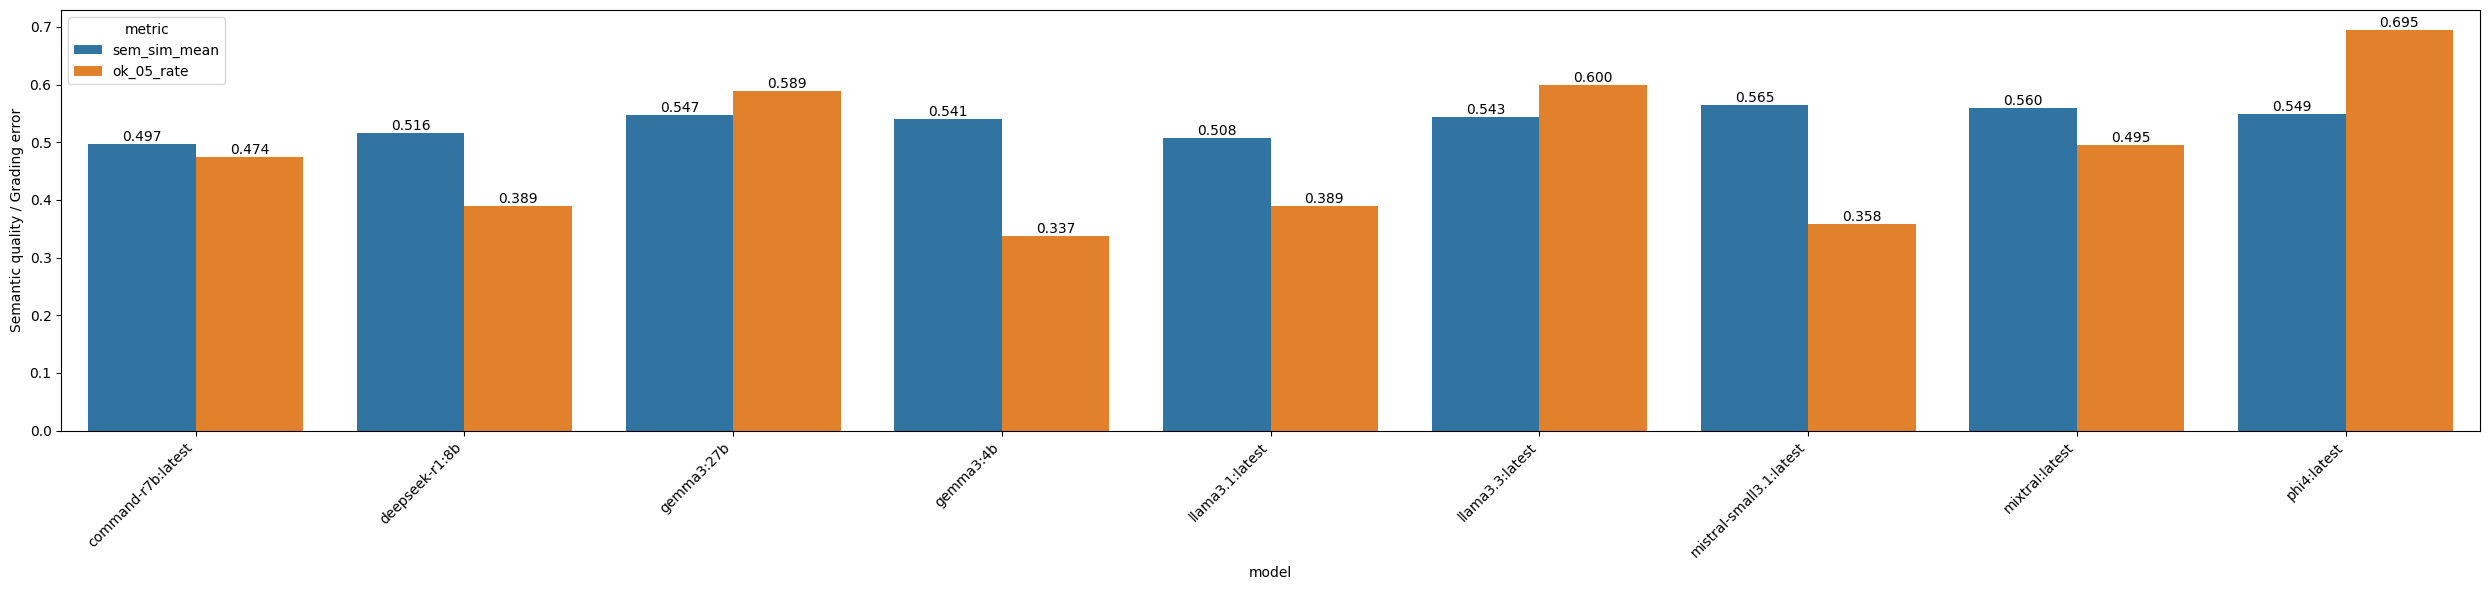

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df["error_perf_neg"] = -final_df["error_perf"]

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_05_rate"],
    var_name="metric",
    value_name="value"
)
plt.figure(figsize=(25,6))

ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()   
plt.show()

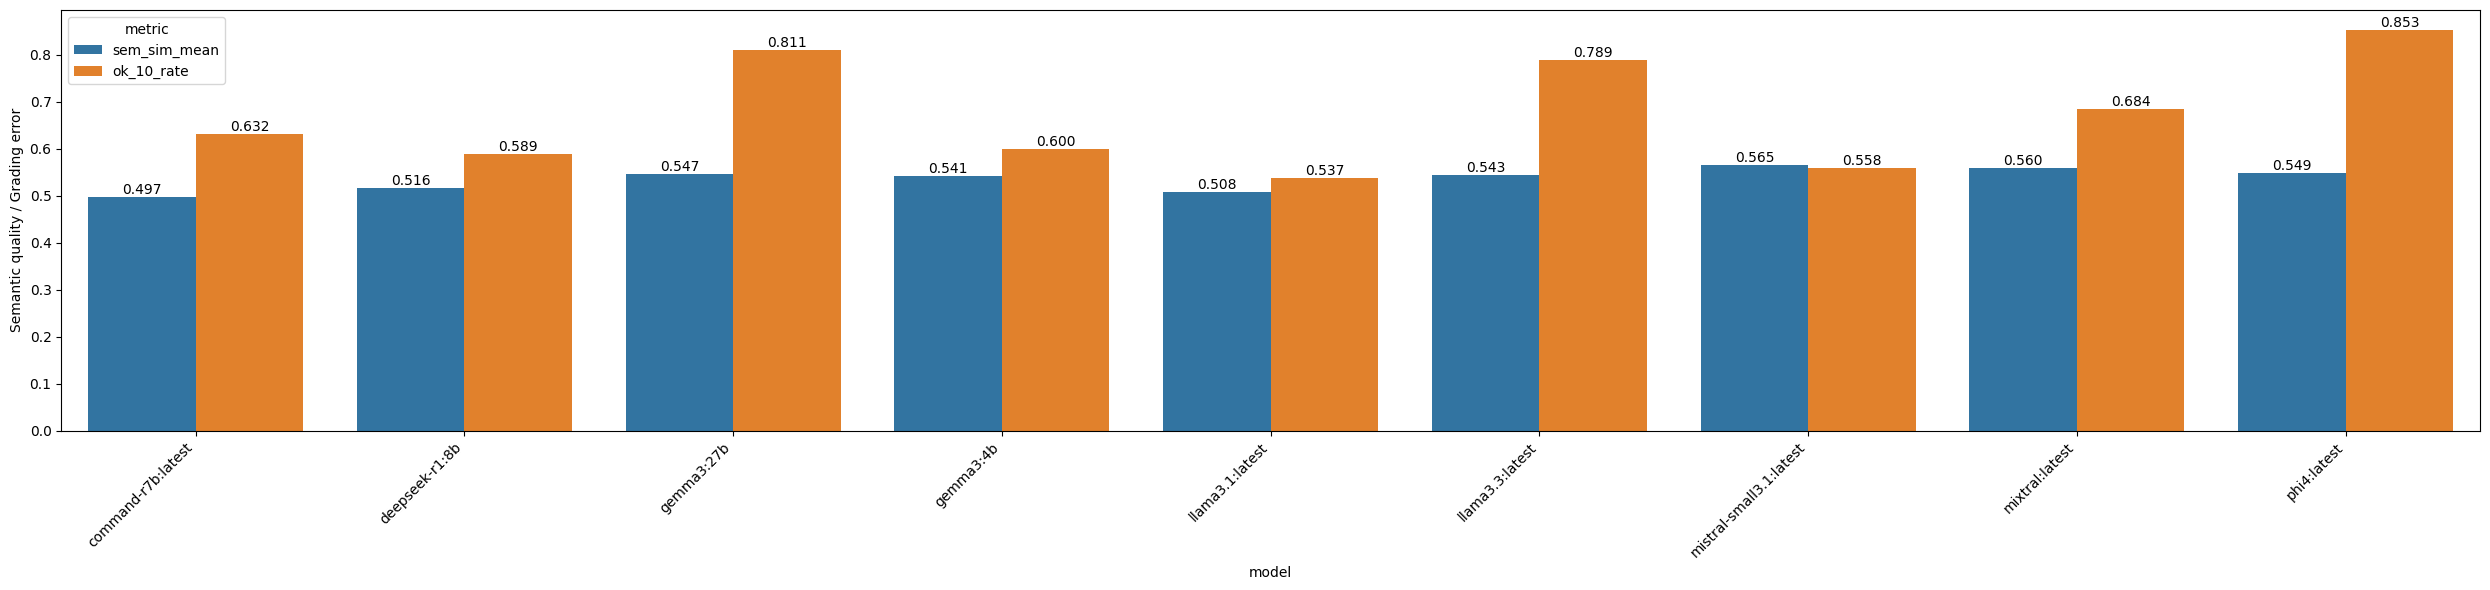

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

final_df["error_perf_neg"] = -final_df["error_perf"]

df_plot = grade_quality.reset_index().melt(
    id_vars="model",
    value_vars=["sem_sim_mean", "ok_10_rate"],
    var_name="metric",
    value_name="value"
)
plt.figure(figsize=(25,6))

ax = sns.barplot(data=df_plot, x="model", y="value", hue="metric")
ax.set_ylabel("Semantic quality / Grading error")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()   
plt.show()

In [13]:
agg = final_df.groupby("model")[[
    "chrf", "error_content_f1", "bertscore_f1",
    # falls du die auch schon hast:
    "abs_error", "error_perf"
]].mean().sort_values("bertscore_f1", ascending=False)

agg

,chrf,error_content_f1,bertscore_f1,abs_error,error_perf
model,,,,,
mixtral:latest,0.383415,0.148563,0.300192,1.063158,0.795764
command-r7b:latest,0.334135,0.154042,0.298112,1.306316,0.751298
llama3.3:latest,0.382138,0.164535,0.293197,0.805263,0.845326
mistral-small3.1:latest,0.377962,0.141957,0.282663,1.215789,0.759699
gemma3:27b,0.365382,0.174087,0.267098,0.794737,0.843226
phi4:latest,0.386414,0.132132,0.266920,0.668421,0.870652
llama3.1:latest,0.325952,0.122742,0.264984,1.331579,0.741378
gemma3:4b,0.333615,0.115388,0.221565,1.226316,0.760677
deepseek-r1:8b,0.326269,0.128610,0.214648,1.215789,0.765764


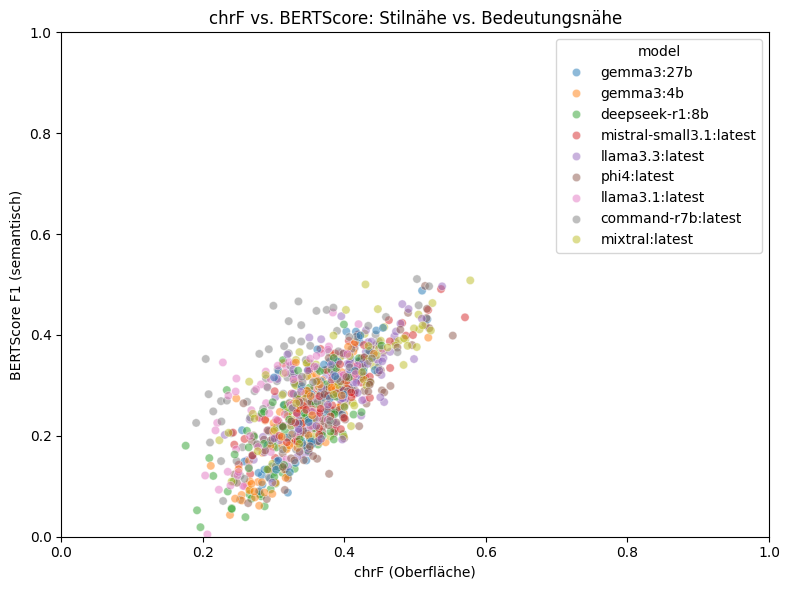

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=final_df, x="chrf", y="bertscore_f1", hue="model", alpha=0.5)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("chrF (Oberfläche)")
plt.ylabel("BERTScore F1 (semantisch)")
plt.title("chrF vs. BERTScore: Stilnähe vs. Bedeutungsnähe")
plt.tight_layout()
plt.show()


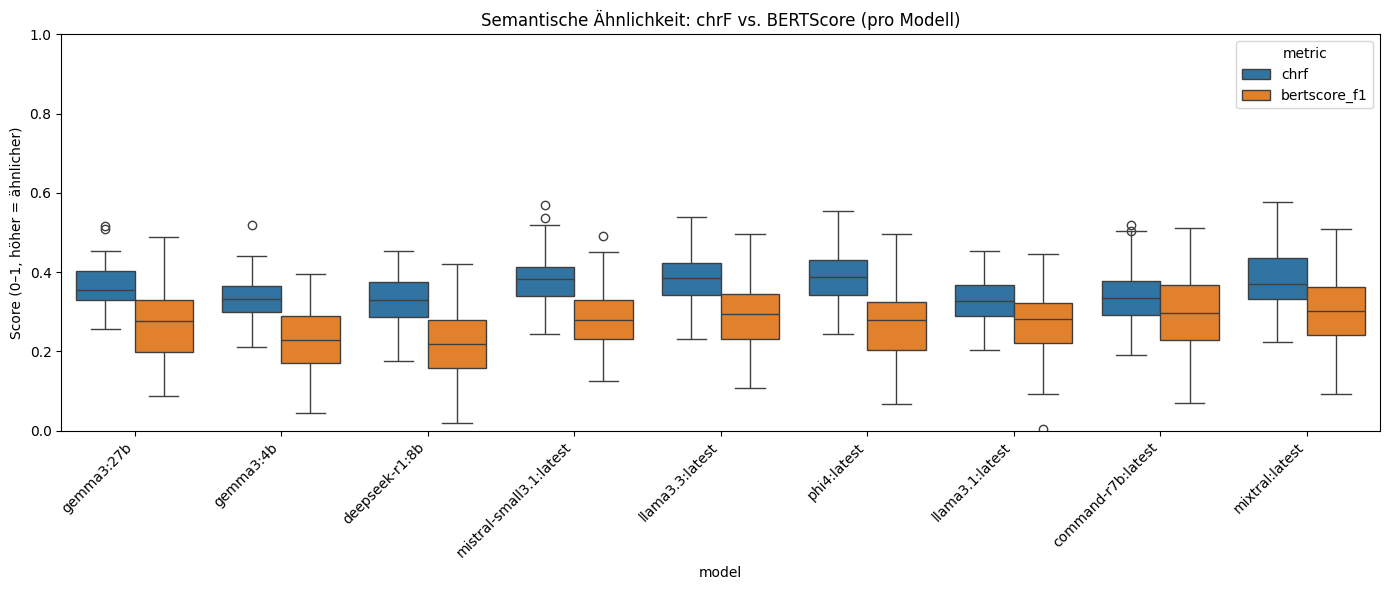

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

metrics = ["chrf", "bertscore_f1"]  # ggf. deine Spaltennamen anpassen

plot_df = final_df.melt(id_vars=["model"], value_vars=metrics,
                  var_name="metric", value_name="score")

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Score (0–1, höher = ähnlicher)")
plt.title("Semantische Ähnlichkeit: chrF vs. BERTScore (pro Modell)")
plt.tight_layout()
plt.show()


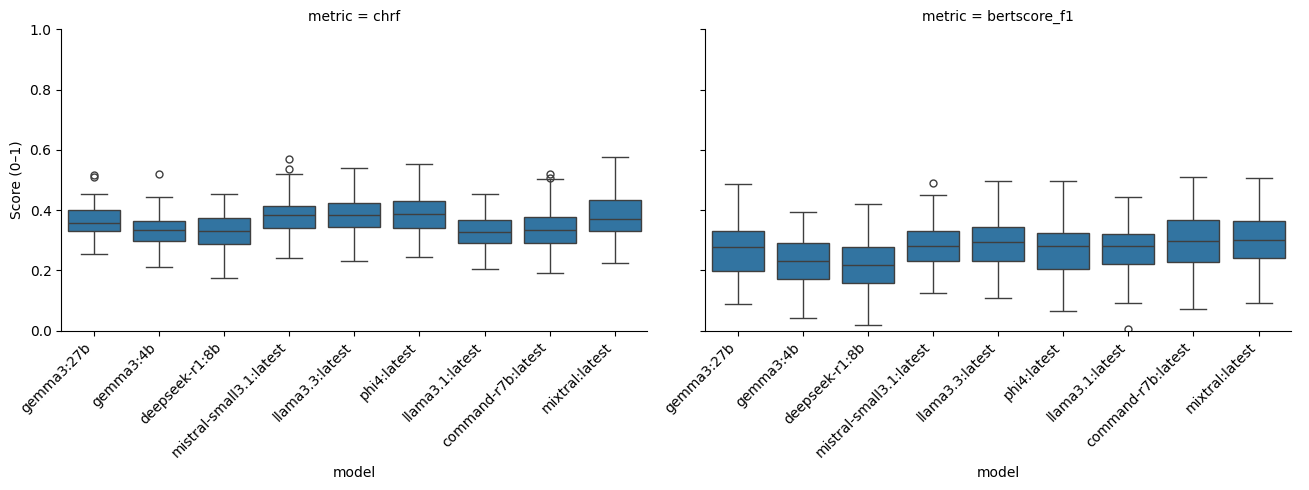

In [16]:
g = sns.catplot(
    data=plot_df, x="model", y="score",
    col="metric", kind="box",
    height=5, aspect=1.3, sharey=True
)
g.set_xticklabels(rotation=45, ha="right")
g.set(ylim=(0, 1), ylabel="Score (0–1)")
plt.tight_layout()
plt.show()


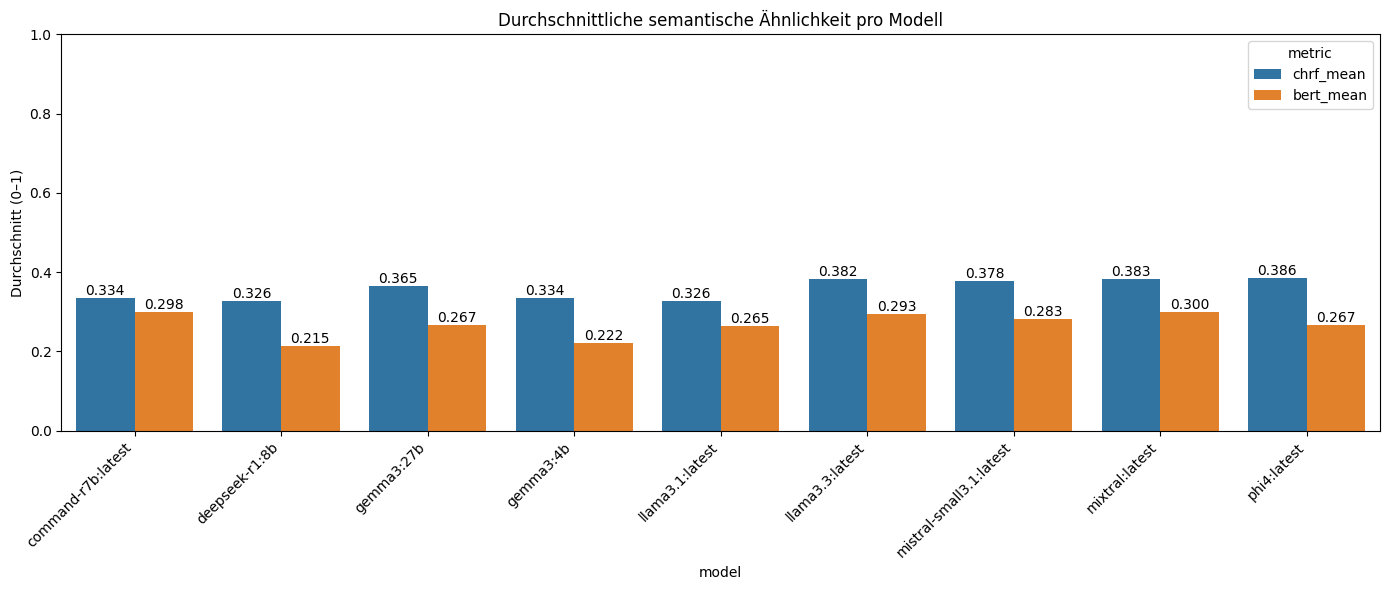

In [17]:
import numpy as np

summary = final_df.groupby("model").agg(
    chrf_mean=("chrf", "mean"),
    chrf_std=("chrf", "std"),
    bert_mean=("bertscore_f1", "mean"),
    bert_std=("bertscore_f1", "std"),
).reset_index()

# Long-Format für Plot
sum_long = summary.melt(id_vars="model",
                        value_vars=["chrf_mean", "bert_mean"],
                        var_name="metric", value_name="mean")

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=sum_long, x="model", y="mean", hue="metric")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Durchschnitt (0–1)")
plt.title("Durchschnittliche semantische Ähnlichkeit pro Modell")
plt.tight_layout()
plt.show()
